<a href="https://colab.research.google.com/github/murilopes7/fine-tuning/blob/main/finetuning-first-model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install unsloth

In [23]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-1B-Instruct",
    max_seq_length = 1024,
    dtype = None,
    load_in_4bit = True,
)

==((====))==  Unsloth 2026.10.1: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 7.5. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-1B-Instruct-unsloth-bnb-4bit as a legacy tokenizer.


In [8]:
import json
from google.colab import drive
drive.mount("/content/drive")
DATA = "/content/drive/MyDrive/smart_home/data"

def load(name):
    return [json.loads(l) for l in open(f"{DATA}/{name}.jsonl")]

train, val, test = load("train"), load("val"), load("test")
print(len(train), len(val), len(test))
for r in train[:5]:
    print(r["command"], "->", r["output"])
print(len({r["command"] for r in train} & {r["command"] for r in test}))

Mounted at /content/drive
300 40 40
Switch off the fan in the office. -> {"actions":[{"device":"fan","room":"office","action":"turn_off"}]}
Turn on the bedroom fan. -> {"actions":[{"device":"fan","room":"bedroom","action":"turn_on"}]}
Turn on the office AC and then close the bathroom blinds. -> {"actions":[{"device":"ac","room":"office","action":"turn_on"},{"device":"blinds","room":"bathroom","action":"close"}]}
Turn off the bedroom TV. -> {"actions":[{"device":"tv","room":"bedroom","action":"turn_off"}]}
Please turn the kitchen TV on. -> {"actions":[{"device":"tv","room":"kitchen","action":"turn_on"}]}
0


In [24]:
import json, os, torch

PROJECT = "/content/drive/MyDrive/smart_home"
SYSTEM_PROMPT = test[0]["messages"][0]["content"]

try:
    FastLanguageModel.for_inference(model)
except Exception as e:
    print("for_inference skipped:", e)

outputs = []
for i, row in enumerate(test):
    msgs = [{"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": row["command"]}]
    prompt = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to("cuda")
    with torch.no_grad():
        gen = model.generate(**inputs, max_new_tokens=128, do_sample=False, use_cache=True)
    text = tokenizer.decode(gen[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    outputs.append(text)
    if i < 3:
        print(row["command"], "->", text, "\n")

with open(f"{PROJECT}/predictions_before.json", "w") as f:
    json.dump(outputs, f, indent=1)
print("saved", len(outputs))

Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Switch off the TV in the living room and then set the office air conditioner to 21 degrees. -> ```
{
  "actions": [
    {
      "type": "switch",
      "device": "TV",
      "command": "off"
    },
    {
      "type": "set",
      "device": "Office Air Conditioner",
      "command": "21"
    }
  ]
}
``` 



Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Can you turn off the lights in the living room? -> ```
{
  "action": "turn off lights in living room",
  "result": {
    "status": "success"
  }
}
``` 



Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Close the kitchen blinds and then turn on the living room air conditioner. -> ```
{
  "actions": [
    {
      "type": "close",
      "target": "kitchen_blinds"
    },
    {
      "type": "turn_on",
      "target": "living_room_air_conditioner"
    }
  ]
}
``` 



Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

saved 40


In [21]:
%cd /content/drive/MyDrive/smart_home
!python data/evaluate.py data/test.jsonl predictions_before.json before

/content/drive/MyDrive/smart_home

| Model: before | Parses as JSON (raw) % | Right schema (raw) % | Exact match (raw) % | Exact match (cleaned) % |
|---|---|---|---|---|
| all (n=40) | 22.5 | 0.0 | 0.0 | 0.0 |
| seen (n=25) | 8.0 | 0.0 | 0.0 | 0.0 |
| unseen (n=15) | 46.7 | 0.0 | 0.0 | 0.0 |


In [22]:
import json
res = json.load(open("results_before.json"))["details"]
for i in (0, 1, 8, 25):
    d = res[i]
    print(d["command"], "\nEXPECTED:", d["expected"], "\nGOT:", d["prediction"], "\n")

Switch off the TV in the living room and then set the office air conditioner to 21 degrees. 
EXPECTED: {"actions":[{"device":"tv","room":"living_room","action":"turn_off"},{"device":"ac","room":"office","action":"set_temperature","value":21}]} 
GOT: ```
{
  "actions": [
    {
      "type": "switch",
      "device": "TV",
      "command": "off"
    },
    {
      "type": "set",
      "device": "Office Air Conditioner",
      "command": "21"
    }
  ]
}
``` 

Can you turn off the lights in the living room? 
EXPECTED: {"actions":[{"device":"light","room":"living_room","action":"turn_off"}]} 
GOT: ```
{
  "action": "turn off lights in living room",
  "result": {
    "status": "success"
  }
}
``` 

Please open the blinds in the living room. 
EXPECTED: {"actions":[{"device":"blinds","room":"living_room","action":"open"}]} 
GOT: ```
{
  "action": "open_blinds",
  "location": "living room",
  "parameters": {
    "blinds_type": "manual",
    "blinds_position": "open"
  }
}
``` 

Hey, could you 

In [26]:
from datasets import Dataset

def to_dataset(rows):
    texts = [tokenizer.apply_chat_template(r["messages"], tokenize=False) for r in rows]
    return Dataset.from_list([{"text": t} for t in texts])

train_ds, val_ds = to_dataset(train), to_dataset(val)
print(train_ds[0]["text"])


<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 07 Oct 2026

Convert the smart-home command into JSON actions. Reply with JSON only.<|eot_id|><|start_header_id|>user<|end_header_id|>

Switch off the fan in the office.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

{"actions":[{"device":"fan","room":"office","action":"turn_off"}]}<|eot_id|>


In [27]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)


Unsloth 2026.10.1 patched 16 layers with 16 QKV layers, 16 O layers and 16 MLP layers.


In [28]:
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported
from unsloth.chat_templates import train_on_responses_only

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_ds,
    eval_dataset = val_ds,
    args = SFTConfig(
        dataset_text_field = "text",
        max_seq_length = 1024,
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        num_train_epochs = 3,
        learning_rate = 2e-4,
        warmup_steps = 5,
        lr_scheduler_type = "linear",
        optim = "adamw_8bit",
        weight_decay = 0.01,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 5,
        eval_strategy = "steps",
        eval_steps = 20,
        save_strategy = "no",
        seed = 3407,
        output_dir = f"{PROJECT}/outputs",
        report_to = "none",
    ),
)

trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|start_header_id|>user<|end_header_id|>\n\n",
    response_part = "<|start_header_id|>assistant<|end_header_id|>\n\n",
)



Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/300 [00:00<?, ? examples/s]

Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/40 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

In [29]:
stats = trainer.train()
print(stats.metrics)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 300 | Num Epochs = 3 | Total steps = 114
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 11,272,192 of 1,247,086,592 (0.90% trained)


Step,Training Loss,Validation Loss
20,0.005862,0.003906
40,0.000850,0.000778
60,0.000360,0.000348
80,0.000313,0.000261
100,0.000208,0.000237
114,0.000249,0.000232


Filter:   0%|          | 0/40 [00:00<?, ? examples/s]

{'train_runtime': 136.4567, 'train_samples_per_second': 6.596, 'train_steps_per_second': 0.835, 'total_flos': 424559926149120.0, 'train_loss': 0.06554889720874806, 'epoch': 3.0}


In [30]:
config = {
    "base_model": "unsloth/Llama-3.2-1B-Instruct",
    "method": "LoRA on a 4-bit base (QLoRA) via Unsloth + TRL SFTTrainer",
    "lora_r": 16, "lora_alpha": 16, "lora_dropout": 0,
    "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    "learning_rate": 2e-4, "epochs": 3, "optimizer": "adamw_8bit", "lr_scheduler": "linear",
    "per_device_batch_size": 2, "grad_accum_steps": 4, "max_seq_length": 1024,
    "seed": 3407, "dataset_seed": 42,
    "train_rows": len(train), "val_rows": len(val), "test_rows": len(test),
    "train_runtime_seconds": stats.metrics.get("train_runtime"),
    "gpu": "Colab T4",
}
with open(f"{PROJECT}/config.json", "w") as f:
    json.dump(config, f, indent=2)
with open(f"{PROJECT}/train_log.json", "w") as f:
    json.dump(trainer.state.log_history, f, indent=1)

import torch
SYSTEM_PROMPT = test[0]["messages"][0]["content"]
FastLanguageModel.for_inference(model)

outputs = []
for i, row in enumerate(test):
    msgs = [{"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": row["command"]}]
    prompt = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to("cuda")
    with torch.no_grad():
        gen = model.generate(**inputs, max_new_tokens=128, do_sample=False, use_cache=True)
    text = tokenizer.decode(gen[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    outputs.append(text)
    if i < 3:
        print(row["command"], "->", text, "\n")

with open(f"{PROJECT}/predictions_after.json", "w") as f:
    json.dump(outputs, f, indent=1)
print("saved", len(outputs))



Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Switch off the TV in the living room and then set the office air conditioner to 21 degrees. -> {"actions":[{"device":"tv","room":"living_room","action":"turn_off"},{"device":"ac","room":"office","action":"set_temperature","value":21}]} 



Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Can you turn off the lights in the living room? -> {"actions":[{"device":"light","room":"living_room","action":"turn_off"}]} 



Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Close the kitchen blinds and then turn on the living room air conditioner. -> {"actions":[{"device":"blinds","room":"kitchen","action":"close"},{"device":"ac","room":"living_room","action":"turn_on"}]} 



Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

saved 40


In [31]:
model.save_pretrained(f"{PROJECT}/lora_adapter")
tokenizer.save_pretrained(f"{PROJECT}/lora_adapter")

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/smart_home/lora_adapter/tokenizer_config.json.


('/content/drive/MyDrive/smart_home/lora_adapter/tokenizer_config.json',
 '/content/drive/MyDrive/smart_home/lora_adapter/chat_template.jinja',
 '/content/drive/MyDrive/smart_home/lora_adapter/tokenizer.json')

In [32]:
%cd /content/drive/MyDrive/smart_home
!python /content/drive/MyDrive/smart_home/data/evaluate.py /content/drive/MyDrive/smart_home/data/test.jsonl /content/drive/MyDrive/smart_home/predictions_after.json after



/content/drive/MyDrive/smart_home

| Model: after | Parses as JSON (raw) % | Right schema (raw) % | Exact match (raw) % | Exact match (cleaned) % |
|---|---|---|---|---|
| all (n=40) | 100.0 | 100.0 | 77.5 | 77.5 |
| seen (n=25) | 100.0 | 100.0 | 100.0 | 100.0 |
| unseen (n=15) | 100.0 | 100.0 | 40.0 | 40.0 |


In [34]:
import json
P = "/content/drive/MyDrive/smart_home"
bef = json.load(open(f"{P}/results_before.json"))["details"]
aft = json.load(open(f"{P}/results_after.json"))["details"]
for b, a in zip(bef, aft):
    if not a["exact_clean"]:
        print(a["kind"], "|", a["command"], "\nEXPECTED:", a["expected"],
              "\nBEFORE:  ", b["prediction"][:150], "\nAFTER:   ", a["prediction"], "\n")

unseen | Close up the bathroom shades and also kill the lamp in the bedroom. 
EXPECTED: {"actions":[{"device":"blinds","room":"bathroom","action":"close"},{"device":"light","room":"bedroom","action":"turn_off"}]} 
BEFORE:   ```
{
  "actions": [
    {
      "type": "close",
      "device": "bathroom_shades",
      "reason": "bathroom"
    },
    {
      "type": "kill",
    
AFTER:    {"actions":[{"device":"shades","room":"bathroom","action":"close"},{"device":"lamp","room":"bedroom","action":"kill"}]} 

unseen | Kill the ceiling fan in the kitchen, please. 
EXPECTED: {"actions":[{"device":"fan","room":"kitchen","action":"turn_off"}]} 
BEFORE:   ```
{
  "command": "kill_ceiling_fan",
  "location": "kitchen",
  "target": "ceiling_fan"
}
``` 
AFTER:    {"actions":[{"device":"fan","room":"kitchen","action":"kill"}]} 

unseen | Hey, could you get the living room ceiling fan going? 
EXPECTED: {"actions":[{"device":"fan","room":"living_room","action":"turn_on"}]} 
BEFORE:   {"command": "get_li

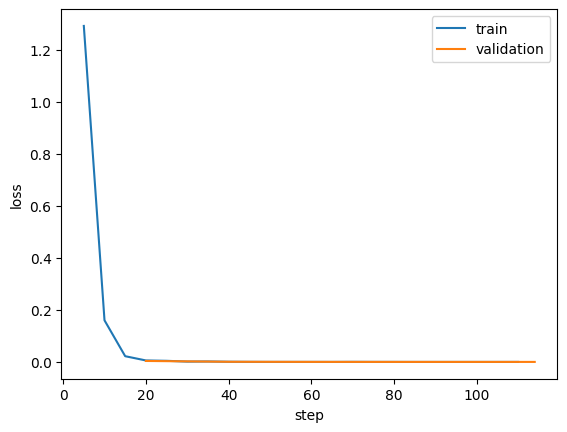

In [35]:
import matplotlib.pyplot as plt
log = json.load(open(f"{P}/train_log.json"))
tr = [(l["step"], l["loss"]) for l in log if "loss" in l]
ev = [(l["step"], l["eval_loss"]) for l in log if "eval_loss" in l]
plt.plot(*zip(*tr), label="train");
plt.plot(*zip(*ev), label="validation")
plt.xlabel("step");
plt.ylabel("loss");
plt.legend();
plt.savefig(f"{P}/loss_curve.png", dpi=150)